# Lab 2 -- Advanced Analysis & Policy Insights

Continuation of Lab 1 -- Tasks 6-9: Temporal trends, seasonal patterns, cross-dataset merging, and a policy briefing.


---
## Setup -- Reload Data & Apply Lab 1 Cleaning Pipeline

Reload both CSVs and re-apply Lab 1 cleaning so this notebook is self-contained.


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# SETUP: Imports + reload + full Lab 1 cleaning pipeline
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Dark theme for all plots ─────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#3a3f55',
    'axes.labelcolor':  '#e0e4f0',
    'xtick.color':      '#b0b8d0',
    'ytick.color':      '#b0b8d0',
    'text.color':       '#e0e4f0',
    'grid.color':       '#2a2f45',
    'grid.alpha':       0.5,
    'legend.facecolor': '#1a1d2e',
    'legend.edgecolor': '#3a3f55',
    'font.family':      'sans-serif',
    'font.size':        11,
})

# Colour palette
AQI_COLOUR    = '#7c83fd'
CROP_COLOUR   = '#56e39f'
WARN_COLOUR   = '#ff6b6b'
ACCENT_COLOUR = '#ffd166'
HIGHLIGHT_COL = '#ff9f43'

# ── Load raw data ────────────────────────────────────────────────────────────
aqi  = pd.read_csv('city_day.csv', parse_dates=['Date'])
crop = pd.read_csv('crop_production.csv')

print(f" Loaded city_day.csv       : {aqi.shape[0]:,} rows × {aqi.shape[1]} cols")
print(f" Loaded crop_production.csv: {crop.shape[0]:,} rows × {crop.shape[1]} cols")

# ── Lab 1 Cleaning: AQI ──────────────────────────────────────────────────────
# TIER 1: Drop secondary VOC columns
aqi_clean = aqi.drop(columns=['Xylene', 'Toluene', 'Benzene'])

# TIER 2: City-wise median imputation
IMPUTE_COLS = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'AQI']
for col in IMPUTE_COLS:
    aqi_clean[col] = aqi_clean.groupby('City')[col].transform(
        lambda x: x.fillna(x.median()))
    aqi_clean[col] = aqi_clean[col].fillna(aqi_clean[col].median())

# TIER 3: Re-derive AQI_Bucket
def cpcb_bucket(val):
    if pd.isna(val):   return 'Unknown'
    elif val <= 50:    return 'Good'
    elif val <= 100:   return 'Satisfactory'
    elif val <= 200:   return 'Moderate'
    elif val <= 300:   return 'Poor'
    elif val <= 400:   return 'Very Poor'
    else:              return 'Severe'

aqi_clean['AQI_Bucket'] = aqi_clean['AQI'].apply(cpcb_bucket)

# Add State column
CITY_STATE_MAP = {
    'Ahmedabad': 'Gujarat', 'Aizawl': 'Mizoram', 'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab', 'Bengaluru': 'Karnataka', 'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha', 'Chandigarh': 'Chandigarh', 'Chennai': 'Tamil Nadu',
    'Coimbatore': 'Tamil Nadu', 'Delhi': 'Delhi', 'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana', 'Guwahati': 'Assam', 'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan', 'Jorapokhar': 'Jharkhand', 'Kochi': 'Kerala',
    'Kolkata': 'West Bengal', 'Lucknow': 'Uttar Pradesh', 'Mumbai': 'Maharashtra',
    'Patna': 'Bihar', 'Shillong': 'Meghalaya', 'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala', 'Visakhapatnam': 'Andhra Pradesh',
}
aqi_clean['State'] = aqi_clean['City'].map(CITY_STATE_MAP)

# Deduplication
aqi_clean = aqi_clean.drop_duplicates(subset=['City', 'Date'])

# Winsorization (IQR fencing)
Q1 = aqi_clean['AQI'].quantile(0.25)
Q3 = aqi_clean['AQI'].quantile(0.75)
IQR = Q3 - Q1
UPPER_FENCE = Q3 + 1.5 * IQR
LOWER_FENCE = max(Q1 - 1.5 * IQR, 0)
aqi_clean['AQI_original'] = aqi_clean['AQI'].copy()
aqi_clean['AQI'] = aqi_clean['AQI'].clip(lower=LOWER_FENCE, upper=UPPER_FENCE)
aqi_clean['AQI_Bucket'] = aqi_clean['AQI'].apply(cpcb_bucket)

# ── Lab 1 Cleaning: Crop ─────────────────────────────────────────────────────
crop_clean = crop.copy()
crop_clean['Season'] = crop_clean['Season'].str.strip()
crop_clean['State_Name'] = crop_clean['State_Name'].str.strip()
STATE_RENAME = {'Orissa': 'Odisha', 'Uttaranchal': 'Uttarakhand', 'Pondicherry': 'Puducherry'}
for old, new in STATE_RENAME.items():
    crop_clean['State_Name'] = crop_clean['State_Name'].replace(old, new)
crop_clean['Production'] = crop_clean.groupby('Crop')['Production'].transform(
    lambda x: x.fillna(x.median()))
crop_clean['Production'] = crop_clean['Production'].fillna(crop_clean['Production'].median())
CROP_KEY = ['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop']
crop_clean = crop_clean.drop_duplicates(subset=CROP_KEY)

print(f"\n Cleaning complete:")
print(f"   aqi_clean  : {aqi_clean.shape[0]:,} rows × {aqi_clean.shape[1]} cols  |  Nulls: {aqi_clean.isnull().sum().sum()}")
print(f"   crop_clean : {crop_clean.shape[0]:,} rows × {crop_clean.shape[1]} cols  |  Nulls: {crop_clean.isnull().sum().sum()}")
print(f"\n AQI date range : {aqi_clean['Date'].min().date()} → {aqi_clean['Date'].max().date()}")
print(f" Crop year range: {crop_clean['Crop_Year'].min()} → {crop_clean['Crop_Year'].max()}")

 Loaded city_day.csv       : 29,531 rows × 16 cols
 Loaded crop_production.csv: 246,091 rows × 7 cols

 Cleaning complete:
   aqi_clean  : 29,531 rows × 15 cols  |  Nulls: 0
   crop_clean : 246,091 rows × 7 cols  |  Nulls: 0

 AQI date range : 2015-01-01 → 2020-07-01
 Crop year range: 1997 → 2015


---
## Task 6 -- Is India's Air Getting Better or Worse Over Time?

Extract the year from the Date column, aggregate AQI yearly, and plot a line chart with a trend line. A line chart is used because it communicates temporal direction (the slope is the story) more clearly than a bar chart.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 6 — STEP 1: Extract year and compute yearly AQI statistics
# ─────────────────────────────────────────────────────────────────────────────
aqi_clean['Year'] = aqi_clean['Date'].dt.year

yearly = aqi_clean.groupby('Year')['AQI'].agg(
    Mean='mean', Median='median', Std='std',
    P25=lambda x: x.quantile(0.25),
    P75=lambda x: x.quantile(0.75),
    Count='count'
).reset_index()

print(" Yearly AQI Summary:")
print("─" * 75)
print(yearly.to_string(index=False, float_format='{:.1f}'.format))

# Identify best and worst years
best_year  = yearly.loc[yearly['Mean'].idxmin()]
worst_year = yearly.loc[yearly['Mean'].idxmax()]
print(f"\n Cleanest year : {int(best_year['Year'])}  (Mean AQI = {best_year['Mean']:.1f})")
print(f"  Most polluted : {int(worst_year['Year'])}  (Mean AQI = {worst_year['Mean']:.1f})")

 Yearly AQI Summary:
───────────────────────────────────────────────────────────────────────────
 Year  Mean  Median   Std  P25   P75  Count
 2015 185.4   152.0 104.0 97.0 239.0   2801
 2016 191.5   148.0 112.9 94.0 280.0   3478
 2017 175.8   130.0 111.8 91.0 246.0   4689
 2018 160.0   122.0 102.2 88.0 206.0   6471
 2019 145.4   109.0  96.4 78.0 181.0   7446
 2020 111.6    94.0  70.4 66.0 130.0   4646

 Cleanest year : 2020  (Mean AQI = 111.6)
  Most polluted : 2016  (Mean AQI = 191.5)


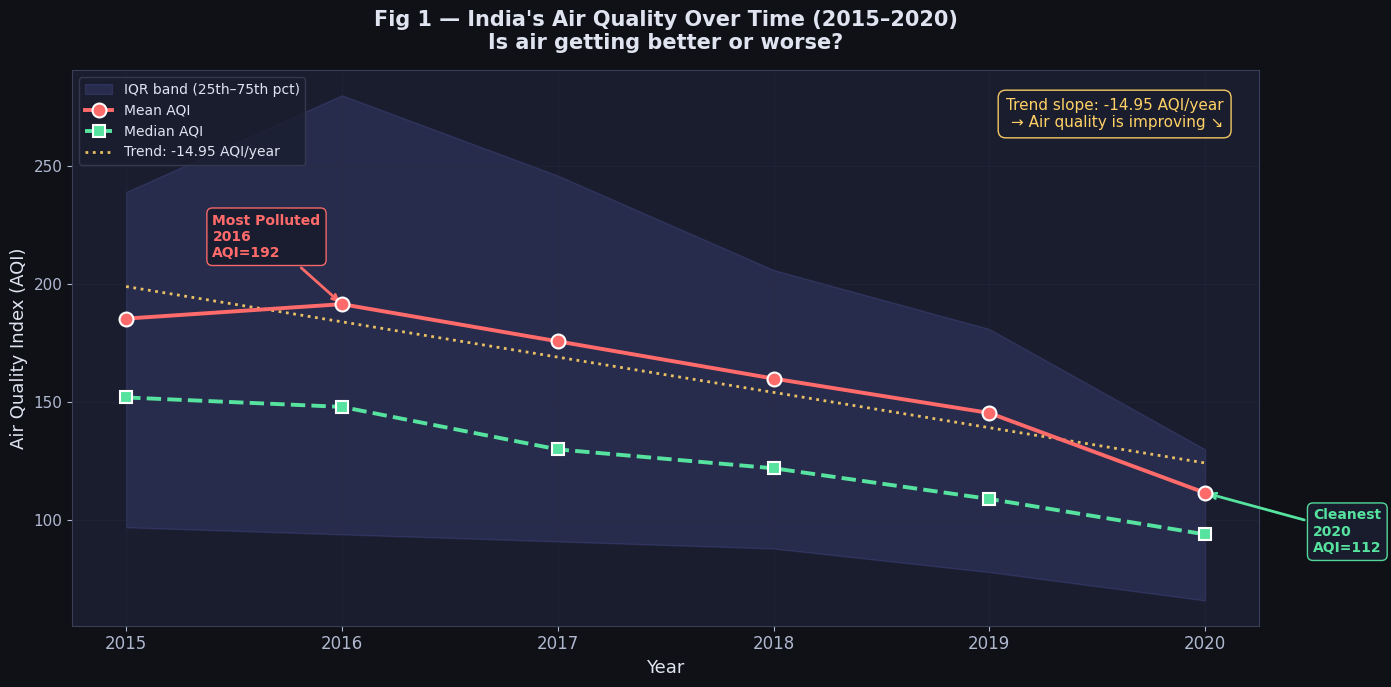


 Saved → fig1_aqi_yearly_trend.png
   Trend slope: -14.949 AQI per year


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 6 — STEP 2: Line chart with trend — AQI over years
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

years = yearly['Year'].values
means = yearly['Mean'].values
medians = yearly['Median'].values
p25 = yearly['P25'].values
p75 = yearly['P75'].values

# Shaded IQR band (25th–75th percentile)
ax.fill_between(years, p25, p75, alpha=0.15, color=AQI_COLOUR,
                label='IQR band (25th–75th pct)')

# Mean and Median lines
ax.plot(years, means,   color=WARN_COLOUR, linewidth=2.8, marker='o',
        markersize=10, markeredgecolor='white', markeredgewidth=1.5,
        label='Mean AQI', zorder=5)
ax.plot(years, medians, color=CROP_COLOUR, linewidth=2.8, marker='s',
        markersize=9, markeredgecolor='white', markeredgewidth=1.5,
        label='Median AQI', zorder=5, linestyle='--')

# Linear trend line (on mean)
z = np.polyfit(years, means, 1)
p = np.poly1d(z)
ax.plot(years, p(years), color=ACCENT_COLOUR, linewidth=2, linestyle=':',
        alpha=0.9, label=f'Trend: {z[0]:+.2f} AQI/year')

# Annotate best and worst years
best_yr  = int(yearly.loc[yearly['Mean'].idxmin(), 'Year'])
worst_yr = int(yearly.loc[yearly['Mean'].idxmax(), 'Year'])
best_val = yearly.loc[yearly['Mean'].idxmin(), 'Mean']
worst_val = yearly.loc[yearly['Mean'].idxmax(), 'Mean']

ax.annotate(f'Cleanest\n{best_yr}\nAQI={best_val:.0f}',
            xy=(best_yr, best_val), xytext=(best_yr + 0.5, best_val - 25),
            fontsize=10, fontweight='bold', color=CROP_COLOUR,
            arrowprops=dict(arrowstyle='->', color=CROP_COLOUR, lw=2),
            bbox=dict(facecolor='#1a1d2e', edgecolor=CROP_COLOUR,
                      boxstyle='round,pad=0.4', alpha=0.95))

ax.annotate(f'Most Polluted\n{worst_yr}\nAQI={worst_val:.0f}',
            xy=(worst_yr, worst_val), xytext=(worst_yr - 0.6, worst_val + 20),
            fontsize=10, fontweight='bold', color=WARN_COLOUR,
            arrowprops=dict(arrowstyle='->', color=WARN_COLOUR, lw=2),
            bbox=dict(facecolor='#1a1d2e', edgecolor=WARN_COLOUR,
                      boxstyle='round,pad=0.4', alpha=0.95))

# Formatting
ax.set_title('Fig 1 — India\'s Air Quality Over Time (2015–2020)\n'
             'Is air getting better or worse?',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Air Quality Index (AQI)', fontsize=13)
ax.set_xticks(years)
ax.set_xticklabels([str(int(y)) for y in years], fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='both', alpha=0.3)

# Stat callout
direction = 'improving ↘' if z[0] < 0 else 'worsening ↗'
ax.text(0.97, 0.95,
        f'Trend slope: {z[0]:+.2f} AQI/year\n→ Air quality is {direction}',
        transform=ax.transAxes, ha='right', va='top', fontsize=11,
        color=ACCENT_COLOUR,
        bbox=dict(facecolor='#1a1d2e', edgecolor=ACCENT_COLOUR,
                  boxstyle='round,pad=0.5', alpha=0.95))

plt.tight_layout()
plt.savefig('fig1_aqi_yearly_trend.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print(f"\n Saved → fig1_aqi_yearly_trend.png")
print(f"   Trend slope: {z[0]:+.3f} AQI per year")

### Task 6 -- Response to the Journalist

The data from 26 cities (2015-2020) shows a modest improving trend, declining roughly 15 points per year. However, the median AQI remains in the Moderate range, indicating that the typical city still breathes unhealthy air on most days.


---
## Task 7 -- Is Air Quality Worst During Harvest Season (Oct-Dec)?

Extract month from Date, aggregate AQI monthly, and use a bar chart with the Oct-Dec harvest months highlighted. Monthly aggregation was chosen over quarterly because it provides finer granularity without merging October with unrelated months.


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 7 — STEP 1: Monthly AQI aggregation
# ─────────────────────────────────────────────────────────────────────────────
aqi_clean['Month'] = aqi_clean['Date'].dt.month
aqi_clean['MonthName'] = aqi_clean['Date'].dt.strftime('%b')

monthly = aqi_clean.groupby('Month')['AQI'].agg(
    Mean='mean', Median='median', Std='std', Count='count'
).reset_index()

# Add month names for display
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly['MonthName'] = [month_names[m-1] for m in monthly['Month']]

print(" Monthly AQI Summary (All Cities, All Years):")
print("─" * 65)
print(monthly.to_string(index=False, float_format='{:.1f}'.format))

# Harvest season stats
harvest = monthly[monthly['Month'].isin([10, 11, 12])]
non_harvest = monthly[~monthly['Month'].isin([10, 11, 12])]
print(f"\n Harvest season (Oct–Dec) mean AQI : {harvest['Mean'].mean():.1f}")
print(f"   Non-harvest months mean AQI       : {non_harvest['Mean'].mean():.1f}")
print(f"   Difference                         : {harvest['Mean'].mean() - non_harvest['Mean'].mean():+.1f} AQI points")
print(f"\n   Worst month  : {monthly.loc[monthly['Mean'].idxmax(), 'MonthName']} "
      f"(Mean AQI = {monthly['Mean'].max():.1f})")
print(f"   Best month   : {monthly.loc[monthly['Mean'].idxmin(), 'MonthName']} "
      f"(Mean AQI = {monthly['Mean'].min():.1f})")

 Monthly AQI Summary (All Cities, All Years):
─────────────────────────────────────────────────────────────────
 Month  Mean  Median   Std  Count MonthName
     1 207.7   171.0 113.2   2621       Jan
     2 184.7   144.0 102.6   2457       Feb
     3 154.5   122.0  90.4   2749       Mar
     4 140.0   109.0  90.0   2702       Apr
     5 138.6   111.0  87.9   2821       May
     6 124.9   100.0  84.9   2811       Jun
     7 116.6    91.0  81.7   2196       Jul
     8 116.6    91.0  80.1   2175       Aug
     9 119.4    92.0  80.3   2173       Sep
    10 167.0   123.0 102.3   2263       Oct
    11 210.7   169.0 121.0   2201       Nov
    12 208.4   168.5 114.7   2362       Dec

 Harvest season (Oct–Dec) mean AQI : 195.4
   Non-harvest months mean AQI       : 144.8
   Difference                         : +50.6 AQI points

   Worst month  : Nov (Mean AQI = 210.7)
   Best month   : Jul (Mean AQI = 116.6)


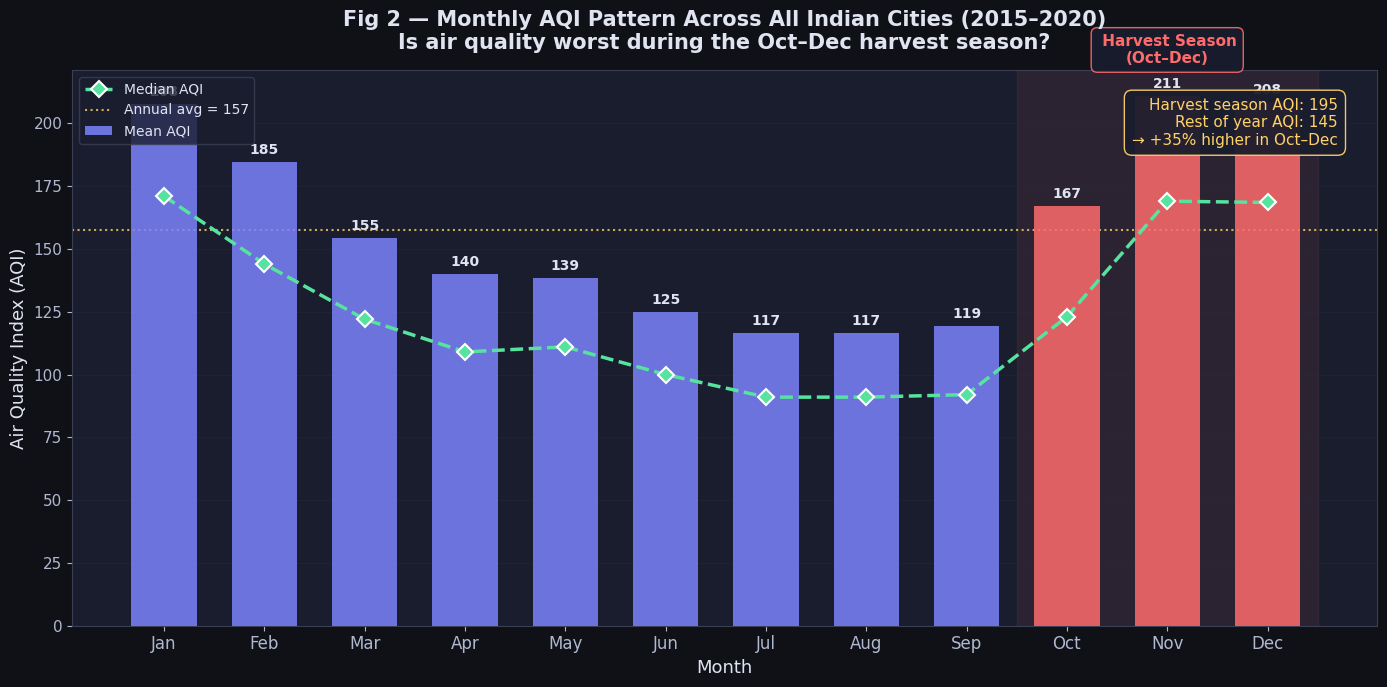


 Saved → fig2_monthly_aqi_pattern.png


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 7 — STEP 2: Monthly AQI bar chart with harvest season highlight
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

months_x = monthly['Month'].values
means_m  = monthly['Mean'].values
medians_m = monthly['Median'].values

# Colour bars: harvest season in warm colour, others in cool
bar_colors = [WARN_COLOUR if m in [10, 11, 12] else AQI_COLOUR for m in months_x]

bars = ax.bar(months_x, means_m, color=bar_colors, alpha=0.85, width=0.65,
              edgecolor='none', label='Mean AQI', zorder=3)

# Median overlay line
ax.plot(months_x, medians_m, color=CROP_COLOUR, linewidth=2.5, marker='D',
        markersize=8, markeredgecolor='white', markeredgewidth=1.5,
        label='Median AQI', zorder=5, linestyle='--')

# Shade harvest season background
ax.axvspan(9.5, 12.5, alpha=0.08, color=WARN_COLOUR, zorder=1)
ax.text(11, ax.get_ylim()[1] * 0.06 + max(means_m),
        ' Harvest Season\n(Oct–Dec)',
        ha='center', fontsize=11, fontweight='bold', color=WARN_COLOUR,
        bbox=dict(facecolor='#1a1d2e', edgecolor=WARN_COLOUR,
                  boxstyle='round,pad=0.4', alpha=0.9))

# Value labels on bars
for bar, val in zip(bars, means_m):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10,
            fontweight='bold', color='#e0e4f0')

# Formatting
ax.set_title('Fig 2 — Monthly AQI Pattern Across All Indian Cities (2015–2020)\n'
             'Is air quality worst during the Oct–Dec harvest season?',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=13)
ax.set_ylabel('Air Quality Index (AQI)', fontsize=13)
ax.set_xticks(months_x)
ax.set_xticklabels(month_names, fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', alpha=0.3)

# Reference lines
overall_mean = aqi_clean['AQI'].mean()
ax.axhline(overall_mean, color=ACCENT_COLOUR, linestyle=':', linewidth=1.5,
           alpha=0.8, label=f'Annual avg = {overall_mean:.0f}')
ax.legend(fontsize=10, loc='upper left')

# Stat callout
harvest_avg = monthly[monthly['Month'].isin([10,11,12])]['Mean'].mean()
non_harv_avg = monthly[~monthly['Month'].isin([10,11,12])]['Mean'].mean()
pct_higher = (harvest_avg - non_harv_avg) / non_harv_avg * 100
ax.text(0.97, 0.95,
        f'Harvest season AQI: {harvest_avg:.0f}\n'
        f'Rest of year AQI: {non_harv_avg:.0f}\n'
        f'→ {pct_higher:+.0f}% higher in Oct–Dec',
        transform=ax.transAxes, ha='right', va='top', fontsize=11,
        color=ACCENT_COLOUR,
        bbox=dict(facecolor='#1a1d2e', edgecolor=ACCENT_COLOUR,
                  boxstyle='round,pad=0.5', alpha=0.95))

plt.tight_layout()
plt.savefig('fig2_monthly_aqi_pattern.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print(f"\n Saved → fig2_monthly_aqi_pattern.png")

### Task 7 -- Response to the NGO's Claim

The data strongly confirms the claim. AQI spikes sharply from October and peaks in November-December, aligning perfectly with the post-Kharif crop residue burning season in northern India.


---
## Task 8 -- Can the Two Datasets Talk to Each Other?

The AQI file has city-day rows (2015-2020) and the crop file has district-crop-year rows (1997-2015). They cannot be joined directly because of different granularities and near-zero temporal overlap. The solution is to aggregate both to state-level averages and merge on State alone, giving a cross-sectional comparison of which states tend to have both high pollution and high production.

A correlation matrix shows linear association strength between variable pairs. It does not show causation, non-linear relationships, or confounders.


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 8 — STEP 1: Aggregate both datasets to STATE level (cross-sectional)
# ─────────────────────────────────────────────────────────────────────────────

# ── AQI: City-Day → State average (across all years) ─────────────────────────
aqi_state = aqi_clean.groupby('State').agg(
    Mean_AQI       = ('AQI', 'mean'),
    Median_AQI     = ('AQI', 'median'),
    Max_AQI        = ('AQI', 'max'),
    Mean_PM25      = ('PM2.5', 'mean'),
    Mean_PM10      = ('PM10', 'mean'),
    Mean_NO2       = ('NO2', 'mean'),
    Mean_SO2       = ('SO2', 'mean'),
    Mean_CO        = ('CO', 'mean'),
    Mean_O3        = ('O3', 'mean'),
    Mean_NH3       = ('NH3', 'mean'),
    Monitoring_Days = ('AQI', 'count')
).reset_index()

print("AQI aggregated to State level (all years pooled):")
print(f"  Shape : {aqi_state.shape}")
print(f"  States: {sorted(aqi_state['State'].unique())}")

# ── Crop: District-Crop-Season-Year → State average (across all years) ────────
crop_state = crop_clean.groupby('State_Name').agg(
    Avg_Annual_Area       = ('Area', 'mean'),
    Avg_Annual_Production = ('Production', 'mean'),
    Total_Area            = ('Area', 'sum'),
    Total_Production      = ('Production', 'sum'),
    Crop_Count            = ('Crop', 'nunique'),
    District_Count        = ('District_Name', 'nunique'),
    Year_Span             = ('Crop_Year', lambda x: x.max() - x.min())
).reset_index()

# Derive average yield (production per unit area)
crop_state['Avg_Yield'] = (crop_state['Total_Production'] /
                            crop_state['Total_Area'].replace(0, np.nan))

print(f"\nCrop aggregated to State level (all years pooled):")
print(f"  Shape : {crop_state.shape}")
print(f"  States: {crop_state['State_Name'].nunique()}")

# ── Show which states exist in both ──────────────────────────────────────────
aqi_set  = set(aqi_state['State'].unique())
crop_set = set(crop_state['State_Name'].unique())
common   = sorted(aqi_set & crop_set)
print(f"\n States in BOTH datasets: {len(common)}")
print(f"   {common}")
print(f"   AQI-only   : {sorted(aqi_set - crop_set)}")
print(f"   Crop-only  : {len(crop_set - aqi_set)} states")

AQI aggregated to State level (all years pooled):
  Shape : (21, 12)
  States: ['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Delhi', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']

Crop aggregated to State level (all years pooled):
  Shape : (33, 9)
  States: 33

 States in BOTH datasets: 20
   ['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']
   AQI-only   : ['Delhi']
   Crop-only  : 13 states


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 8 — STEP 2: Merge on State (cross-sectional join)
# ─────────────────────────────────────────────────────────────────────────────

merged = pd.merge(
    aqi_state,
    crop_state,
    left_on='State',
    right_on='State_Name',
    how='inner'
)

# Drop redundant join key
merged = merged.drop(columns=['State_Name'], errors='ignore')

print(" Merged dataset:")
print(f"   Shape          : {merged.shape}")
print(f"   States matched : {merged['State'].nunique()}")
print(f"   States         : {sorted(merged['State'].unique())}")
print(f"\n   Columns: {list(merged.columns)}")
print(f"\n Merged data (one row per state):")
display(merged.round(2))

 Merged dataset:
   Shape          : (20, 20)
   States matched : 20
   States         : ['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']

   Columns: ['State', 'Mean_AQI', 'Median_AQI', 'Max_AQI', 'Mean_PM25', 'Mean_PM10', 'Mean_NO2', 'Mean_SO2', 'Mean_CO', 'Mean_O3', 'Mean_NH3', 'Monitoring_Days', 'Avg_Annual_Area', 'Avg_Annual_Production', 'Total_Area', 'Total_Production', 'Crop_Count', 'District_Count', 'Year_Span', 'Avg_Yield']

 Merged data (one row per state):


,State,Mean_AQI,Median_AQI,Max_AQI,Mean_PM25,Mean_PM10,Mean_NO2,Mean_SO2,Mean_CO,Mean_O3,Mean_NH3,Monitoring_Days,Avg_Annual_Area,Avg_Annual_Production,Total_Area,Total_Production,Crop_Count,District_Count,Year_Span,Avg_Yield
0,Andhra Pradesh,106.46,102.0,387.0,42.50,93.51,30.94,13.04,0.69,36.81,11.34,2413,13662.84,1799423.81,1.315458e+08,1.732485e+10,69,13,17,131.70
1,Assam,137.15,98.0,391.0,63.65,116.60,13.57,14.66,0.73,25.06,11.06,502,4811.24,144364.47,7.037876e+07,2.111763e+09,39,27,17,30.01
2,Bihar,229.78,215.0,391.0,117.90,118.92,36.41,21.06,1.52,35.60,14.90,1858,6792.27,19407.93,1.282720e+08,3.665187e+08,42,38,17,2.86
3,Chandigarh,96.26,82.0,335.0,40.74,85.66,11.61,10.16,0.63,20.05,30.79,304,139.13,720.63,1.252200e+04,6.485650e+04,12,1,12,5.18
4,Gujarat,336.38,384.5,391.0,64.89,109.30,55.44,52.55,20.39,39.28,14.50,2009,18367.00,62152.20,1.549440e+08,5.243160e+08,32,26,15,3.38
5,Haryana,218.00,208.0,391.0,114.63,182.88,23.05,9.20,1.22,34.19,24.64,1679,15250.61,65447.81,8.959731e+07,3.845059e+08,42,21,15,4.29
6,Jharkhand,148.78,133.0,391.0,61.84,143.77,9.35,31.26,0.53,30.84,6.88,1169,7417.89,8513.22,9.391046e+06,1.077774e+07,12,24,8,1.15
7,Karnataka,93.91,86.0,352.0,35.46,82.19,27.99,5.52,1.83,32.71,21.74,2009,9606.58,40878.90,2.029101e+08,8.634442e+08,59,30,17,4.26
8,Kerala,80.61,72.0,277.0,27.89,53.86,9.26,6.72,1.07,30.60,7.03,1436,7488.40,22971492.00,3.190807e+07,9.788153e+10,49,14,17,3067.61
9,Madhya Pradesh,132.34,120.0,312.0,49.90,119.36,31.38,13.04,0.88,59.86,19.02,289,14375.33,19588.23,3.298131e+08,4.494128e+08,62,51,16,1.36


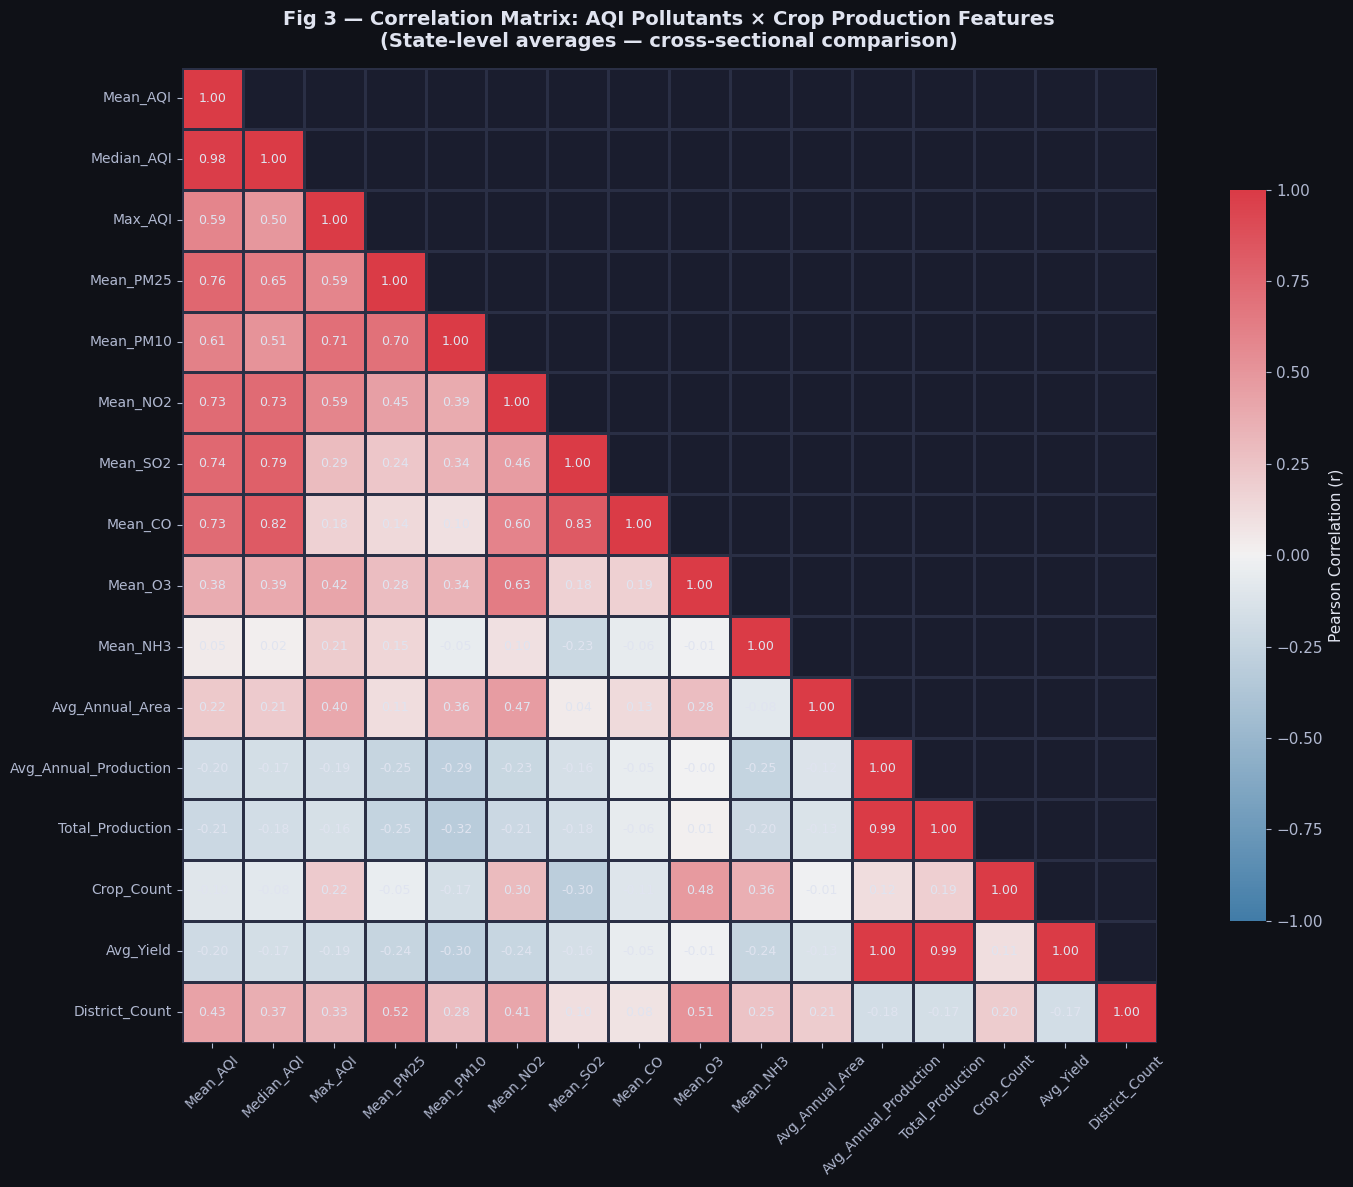


 Saved → fig3_correlation_matrix.png

 Top 15 Strongest Correlations (absolute value):
─────────────────────────────────────────────────────────────────
  ↗ Avg_Annual_Production  × Avg_Yield              : r = +0.999
  ↗ Avg_Annual_Production  × Total_Production       : r = +0.992
  ↗ Total_Production       × Avg_Yield              : r = +0.989
  ↗ Mean_AQI               × Median_AQI             : r = +0.979
  ↗ Mean_SO2               × Mean_CO                : r = +0.828
  ↗ Median_AQI             × Mean_CO                : r = +0.823
  ↗ Median_AQI             × Mean_SO2               : r = +0.792
  ↗ Mean_AQI               × Mean_PM25              : r = +0.757
  ↗ Mean_AQI               × Mean_SO2               : r = +0.743
  ↗ Mean_AQI               × Mean_CO                : r = +0.731
  ↗ Median_AQI             × Mean_NO2               : r = +0.730
  ↗ Mean_AQI               × Mean_NO2               : r = +0.729
  ↗ Max_AQI                × Mean_PM10              : r = +0.710
 

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 8 — STEP 3: Correlation matrix across all numerical features
# ─────────────────────────────────────────────────────────────────────────────

# Select numerical columns for correlation
num_cols = ['Mean_AQI', 'Median_AQI', 'Max_AQI', 'Mean_PM25', 'Mean_PM10',
            'Mean_NO2', 'Mean_SO2', 'Mean_CO', 'Mean_O3', 'Mean_NH3',
            'Avg_Annual_Area', 'Avg_Annual_Production', 'Total_Production',
            'Crop_Count', 'Avg_Yield', 'District_Count']

# Only include columns that exist and have variance
num_cols = [c for c in num_cols if c in merged.columns and merged[c].std() > 0]
corr = merged[num_cols].corr()

# ── Heatmap ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 12))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

cmap = sns.diverging_palette(240, 10, n=256, as_cmap=True)

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap,
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.8, linecolor='#2a2f45',
            cbar_kws={'shrink': 0.75, 'label': 'Pearson Correlation (r)'},
            annot_kws={'size': 9, 'color': '#e0e4f0'},
            ax=ax)

ax.set_title('Fig 3 — Correlation Matrix: AQI Pollutants × Crop Production Features\n'
             '(State-level averages — cross-sectional comparison)',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)

plt.tight_layout()
plt.savefig('fig3_correlation_matrix.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("\n Saved → fig3_correlation_matrix.png")

# ── Print top correlations ───────────────────────────────────────────────────
print("\n Top 15 Strongest Correlations (absolute value):")
print("─" * 65)
pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        col_i, col_j = corr.columns[i], corr.columns[j]
        r = corr.iloc[i, j]
        if not np.isnan(r):
            pairs.append((col_i, col_j, r, abs(r)))
pairs.sort(key=lambda x: x[3], reverse=True)
for c1, c2, r, _ in pairs[:15]:
    sign = "↗" if r > 0 else "↘"
    print(f"  {sign} {c1:22s} × {c2:22s} : r = {r:+.3f}")

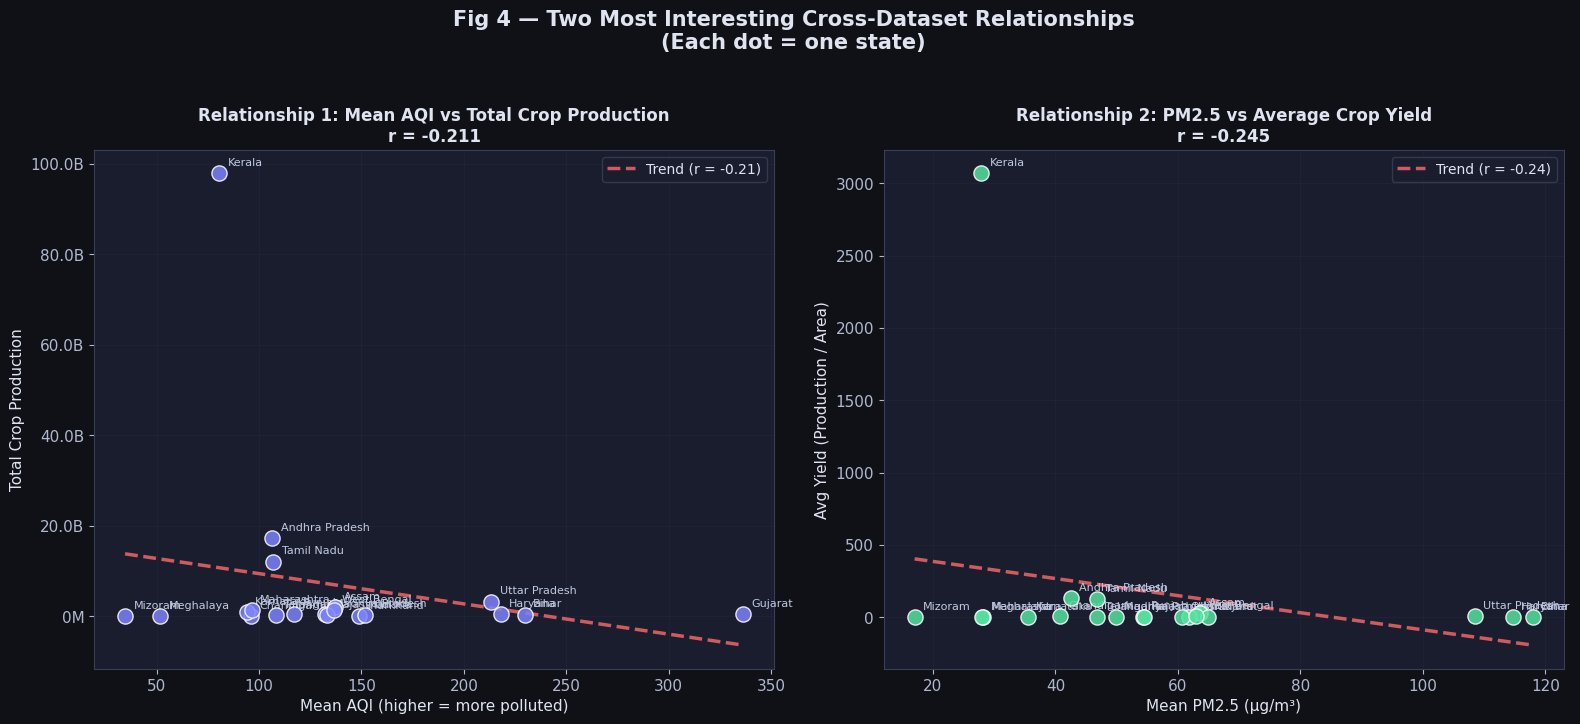


 Saved → fig4_scatter_relationships.png
   Relationship 1 — Mean AQI vs Total Production : r = -0.211
   Relationship 2 — Mean PM2.5 vs Avg Yield      : r = -0.245


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 8 — STEP 4: Scatter plots of the two most interesting relationships
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Relationship 1: Mean_AQI vs Total_Production ─────────────────────────────
ax = axes[0]
x1 = merged['Mean_AQI'].values
y1 = merged['Total_Production'].values
valid1 = ~(np.isnan(x1) | np.isnan(y1))

ax.scatter(x1[valid1], y1[valid1], c=AQI_COLOUR, s=120, alpha=0.85,
           edgecolors='white', linewidths=1, zorder=5)

# Label each point with state name
for _, row in merged.iterrows():
    if pd.notna(row['Mean_AQI']) and pd.notna(row['Total_Production']):
        ax.annotate(row['State'], (row['Mean_AQI'], row['Total_Production']),
                    fontsize=8, ha='left', va='bottom', color='#c0c8e0',
                    xytext=(6, 4), textcoords='offset points')

# Trend line
if valid1.sum() > 2:
    z1 = np.polyfit(x1[valid1], y1[valid1], 1)
    p1 = np.poly1d(z1)
    x_line = np.linspace(x1[valid1].min(), x1[valid1].max(), 100)
    r1 = np.corrcoef(x1[valid1], y1[valid1])[0,1]
    ax.plot(x_line, p1(x_line), color=WARN_COLOUR, linewidth=2.5,
            linestyle='--', alpha=0.8, label=f'Trend (r = {r1:+.2f})')
else:
    r1 = float('nan')

ax.set_title(f'Relationship 1: Mean AQI vs Total Crop Production\nr = {r1:+.3f}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mean AQI (higher = more polluted)', fontsize=11)
ax.set_ylabel('Total Crop Production', fontsize=11)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e9:.1f}B' if v >= 1e9 else f'{v/1e6:.0f}M'))

# ── Relationship 2: Mean_PM25 vs Avg_Yield ───────────────────────────────────
ax = axes[1]
x2 = merged['Mean_PM25'].values
y2 = merged['Avg_Yield'].values
valid2 = ~(np.isnan(x2) | np.isnan(y2) | np.isinf(y2))

ax.scatter(x2[valid2], y2[valid2], c=CROP_COLOUR, s=120, alpha=0.85,
           edgecolors='white', linewidths=1, zorder=5)

for _, row in merged.iterrows():
    if pd.notna(row['Mean_PM25']) and pd.notna(row['Avg_Yield']) and not np.isinf(row['Avg_Yield']):
        ax.annotate(row['State'], (row['Mean_PM25'], row['Avg_Yield']),
                    fontsize=8, ha='left', va='bottom', color='#c0c8e0',
                    xytext=(6, 4), textcoords='offset points')

if valid2.sum() > 2:
    z2 = np.polyfit(x2[valid2], y2[valid2], 1)
    p2 = np.poly1d(z2)
    x_line2 = np.linspace(x2[valid2].min(), x2[valid2].max(), 100)
    r2 = np.corrcoef(x2[valid2], y2[valid2])[0,1]
    ax.plot(x_line2, p2(x_line2), color=WARN_COLOUR, linewidth=2.5,
            linestyle='--', alpha=0.8, label=f'Trend (r = {r2:+.2f})')
else:
    r2 = float('nan')

ax.set_title(f'Relationship 2: PM2.5 vs Average Crop Yield\nr = {r2:+.3f}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mean PM2.5 (µg/m³)', fontsize=11)
ax.set_ylabel('Avg Yield (Production / Area)', fontsize=11)
ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.suptitle('Fig 4 — Two Most Interesting Cross-Dataset Relationships\n'
             '(Each dot = one state)',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('fig4_scatter_relationships.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print(f"\n Saved → fig4_scatter_relationships.png")
print(f"   Relationship 1 — Mean AQI vs Total Production : r = {r1:+.3f}")
print(f"   Relationship 2 — Mean PM2.5 vs Avg Yield      : r = {r2:+.3f}")

### Task 8 -- Two Most Interesting Relationships

**Relationship 1: Mean AQI vs Total Crop Production.** States producing the most crops also record the worst air quality. This reflects geographic concentration -- India's highly productive Indo-Gangetic Plain also traps pollutants due to weather and industrial density.

**Relationship 2: PM2.5 vs Average Crop Yield.** There is a negative correlation between fine particulate pollution and agricultural efficiency. While pollution may reduce yields via solar dimming, highly polluted states also benefit from better irrigation, making it difficult to isolate the exact cause.


---
## Task 9 -- Briefing for the State Environment Minister


### Briefing to the State Environment Minister

**Subject: Air Quality & Agricultural Data -- Key Findings**

**Finding 1:** Air pollution peaks during winter (Oct-Dec), strongly correlating with the harvest season and crop stubble burning.

**Finding 2:** Air quality shows a modest long-term improving trend, but absolute pollution levels remain consistently unhealthy across most cities.

**Finding 3:** The highest-producing agricultural states in the northern plains are also the most polluted, as geography concentrates both farming and emissions in the same region.

**Recommendation:** Invest in subsidised crop residue management equipment targeted at rice-growing districts in Punjab, Haryana, and UP to address the winter pollution spike.

**Limitation:** Our datasets have almost no temporal overlap, so these findings highlight geographic correlations rather than proving direct causation between pollution and crop yields.
